# Kkcalc for S K-edge NEXAFS

Try using Peter D's code with main KKcalc package code

## Setup

### Imports

In [ ]:
from kkcalc import 

In [2]:
# Imports:
import sys
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import pandas as pd
import dask.array as da
import kkcalc
from kkcalc import data
from kkcalc import kk
from scipy import optimize
from tqdm.auto import tqdm

# nexafsFxnsPath = basePath.joinpath('misc_older_work/nexafs_analysis')
# sys.path.append(str(nexafsFxnsPath))
# import nexafs_fxns as nf  # custom nexafs functions used throughout this notebook

/Users/andrew/local_data_analysis/repos/kkcalc/kkcalc/data.py:217: SyntaxWarning: invalid escape sequence '\('
  m=re.search('((?P<Element>[A-Z][a-z]?)|\((?P<Paren>.*)\))(?P<Number>\d*(\.\d+)?)(?P<Remainder>.*)',Formula)


### Define paths/objects

In [2]:
basePath = pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite')
nfZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/fl_nexafs_zarrs')
lpZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/lamella_vs_energy_zarrs')
initialMDPath = basePath.joinpath('local_data/PM6_MD_sim/simulations/initial')

scratchPath = basePath.joinpath('local_data/kkcalc_scratch')
# nfZarrsPath.exists()

## NEXAFS -> Atomic Scattering Factors (kkcalc)

### Load NEXAF data

In [3]:
# Define path to zarr
nfZarrPath = sorted(nfZarrsPath.glob('*.zarr'))[0]
nfZarrPath

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/local_data/trexs_nexafs_2024C3/fl_nexafs_zarrs/fl_nexafs_v1.zarr')

In [4]:
# Load zarr into xarray
nf_DA = xr.open_zarr(nfZarrPath)['fl_nexafs'].compute()
nf_DA

<xarray.DataArray 'fl_nexafs' (sample_ID: 9, energy: 45)> Size: 3kB
array([[-3.89092436e-01, -2.47907231e-01, -6.18634231e-02,
        -6.31710149e-02,  1.25034438e-01,  1.96792221e-01,
         2.70413231e-01,  3.32284538e-01,  3.64256886e-01,
         3.66491825e-01,  4.05829143e-01,  3.31069054e-01,
         4.18453420e-01,  4.00604109e-01,  3.91258970e-01,
         4.03141174e-01,  4.05631783e-01,  3.56237279e-01,
         3.14174234e-01,  3.81338930e-01,  3.97597957e-01,
         4.48764039e-01,  3.92270182e-01,  4.06274801e-01,
         4.09584756e-01,  3.98278361e-01,  5.21701310e-01,
         4.70965951e-01,  5.60361954e-01,  4.43013115e-01,
         4.18653324e-01,  4.49377135e-01,  4.90907964e-01,
         4.67073143e-01,  4.74006340e-01,  5.26479230e-01,
         4.98502340e-01,  6.12920689e-01,  6.59798062e-01,
         6.74381604e-01,  6.29333098e-01,  7.42723211e-01,
         8.62994003e-01,  9.65187453e-01,  1.03481255e+00],
       [ 1.27540166e-02,  4.53338364e-04,  9.43366862e-05,
         1.04032946e-03, -1.13466615e-03, -4.60682242e-03,
        -1.65060411e-03,  5.78943286e-03,  2.28461611e-02,
         6.22366976e-02,  2.05800422e-01,  3.30961471e-01,
         5.56709787e-01,  9.29178813e-01,  1.30712862e+00,
...
         1.73195657e+00,  1.43901047e+00,  1.38972174e+00,
         1.50348158e+00,  1.56378211e+00,  1.56643722e+00,
         1.55283393e+00,  1.52888638e+00,  1.49525225e+00,
         1.46434308e+00,  1.47076950e+00,  1.24612489e+00,
         1.06726174e+00,  9.95115486e-01,  1.00488451e+00],
       [ 3.22698624e-02,  1.41044069e-02,  5.02829456e-03,
        -1.62567303e-03, -3.40262153e-03,  3.83046106e-03,
         1.04400575e-02,  1.87486340e-02,  3.27412328e-02,
         8.16229362e-02,  2.64911965e-01,  4.12089478e-01,
         6.91034802e-01,  1.13621920e+00,  1.56274150e+00,
         2.01678798e+00,  2.71329129e+00,  3.77046891e+00,
         4.70639696e+00,  4.89905993e+00,  4.12831894e+00,
         3.01226529e+00,  2.20682448e+00,  1.81443494e+00,
         1.69302136e+00,  1.67270203e+00,  1.66810589e+00,
         1.67358768e+00,  1.65482545e+00,  1.64047190e+00,
         1.61756516e+00,  1.40598954e+00,  1.37072093e+00,
         1.45450933e+00,  1.49404363e+00,  1.48942587e+00,
         1.46492563e+00,  1.44858182e+00,  1.42610326e+00,
         1.41343736e+00,  1.41431985e+00,  1.21886447e+00,
         1.06983485e+00,  9.93358928e-01,  1.00664107e+00]])
Coordinates:
  * energy     (energy) float64 360B 2.442e+03 2.447e+03 ... 2.507e+03 2.517e+03
  * sample_ID  (sample_ID) <U5 180B 'SiN-0' 'SiN-1' 'SiN-2' ... 'SiN-7' 'SiN-8'
    theta      int64 8B 90

In [5]:
# Initalize dictionaries for sample names (for titles & saving files)
sn = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7 CF + 0.0% CN',
    'SiN-2': 'PM7 CF + 5.0% CN',
    'SiN-3': 'PM6 CF + 0.0% CN',
    'SiN-4': 'PM6 CF + 5.0% CN',
    'SiN-5': 'PM7 CF + 1.0% CN',
    'SiN-6': 'PM7 CF + 0.5% CN',
    'SiN-7': 'PM6 CF + 1.0% CN',
    'SiN-8': 'PM6 CF + 0.5% CN',    
}

sn_id = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7_CF',
    'SiN-2': 'PM7_5CN-CF',
    'SiN-3': 'PM6_CF',
    'SiN-4': 'PM6_5CN-CF',
    'SiN-5': 'PM7_1CN-CF',
    'SiN-6': 'PM7_p5CN-CF',
    'SiN-7': 'PM6_1CN-CF',
    'SiN-8': 'PM6_p5CN-CF',
}

### Run kkcalc for atomic scattering factors

In [6]:
e_slice = slice(2465,2520)

(40, 2)


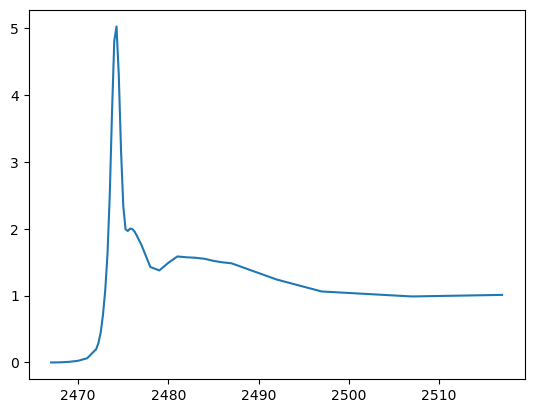

In [7]:
%matplotlib inline
plt.close('all')

# Put into numpy array (1st column energy, 2nd column nexafs) and check data
np_nf = np.array([nf_DA.sel(energy=e_slice).energy,nf_DA.sel(energy=e_slice).sel(sample_ID='SiN-4').data]).T
# np_nf = np.array([nf_DA.sel(energy=e_slice).energy,nf_DA.sel(energy=e_slice).sel(sample_ID='SiN-2').data]).T
print(np_nf.shape)

plt.plot(np_nf[:,0], np_nf[:,1])
plt.show()


In [11]:
ASF_Data.shape

(515, 5)

In [28]:
# Use OG code:

PM6 = "C68H76F2O2S8"
# PM6 = "S1"
spectra_e = np_nf[:,0]
spectra_abs = np_nf[:,1]
e_min = 2465
e_max = 2510

# Peter D's kkcalc function for numpy arrays:
# Parse chemical formula and calculate formula mass
stoichiometry = kk.data.ParseChemicalFormula(PM6)
formula_mass = data.calculate_FormulaMass(stoichiometry)

# Calculate Atomic Scattering Factors from Henke Database
ASF_E, ASF_Data = kk.data.calculate_asf(stoichiometry)
ASF_Data2 = kk.data.coeffs_to_ASF(ASF_E, np.vstack((ASF_Data, ASF_Data[-1])))

# Merge Henke data with NEXAFS
merged = data.merge_spectra(np.column_stack((spectra_e, spectra_abs)), ASF_E, ASF_Data, merge_points=(e_min,e_max), add_background=False, fix_distortions=False, plotting_extras=True)

# Calculate relativistic correction
correction = kk.calc_relativistic_correction(stoichiometry)

# Calculate real component of ASF from merged data
real = kk.KK_PP(merged[2][:,0], merged[0], merged[1], correction)

    
# # Conversion to delta and beta
# delta = data.convert_data(np.column_stack((merged[2][:,0],real)),'ASF','refractive_index', Density=density, Formula_Mass=formula_mass)
# beta = data.convert_data(merged[2],'ASF','refractive_index', Density=density, Formula_Mass=formula_mass)
    


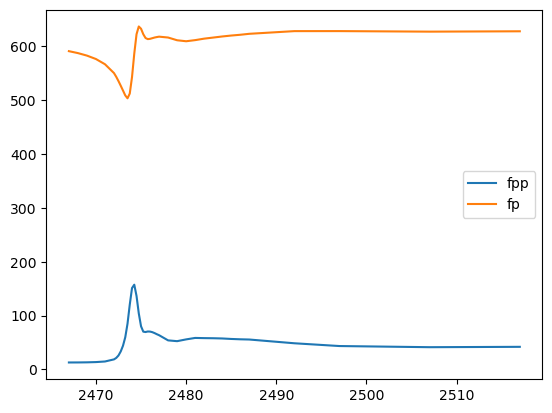

In [29]:
plt.plot(spectra_e, merged[2][:,1], label='fpp')
plt.plot(spectra_e, real, label='fp')
plt.legend()
plt.show()

## Fitting lamella peak intensity profile

### Load experimental lamella peak intensity data

In [ ]:
# Initalize dictionaries for sample names (for titles & saving files)
sn = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7 CF + 0.0% CN',
    'SiN-2': 'PM7 CF + 5.0% CN',
    'SiN-3': 'PM6 CF + 0.0% CN',
    'SiN-4': 'PM6 CF + 5.0% CN',
    'SiN-5': 'PM7 CF + 1.0% CN',
    'SiN-6': 'PM7 CF + 0.5% CN',
    'SiN-7': 'PM6 CF + 1.0% CN',
    'SiN-8': 'PM6 CF + 0.5% CN',    
}

sn_id = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7_CF',
    'SiN-2': 'PM7_5CN-CF',
    'SiN-3': 'PM6_CF',
    'SiN-4': 'PM6_5CN-CF',
    'SiN-5': 'PM7_1CN-CF',
    'SiN-6': 'PM7_p5CN-CF',
    'SiN-7': 'PM6_1CN-CF',
    'SiN-8': 'PM6_p5CN-CF',
}

In [ ]:
# Define path to zarr
lpZarrPath = sorted(lpZarrsPath.glob('*.zarr'))[1]
lpZarrPath

In [ ]:
# Load zarr into xarray
lp_DA = xr.open_zarr(lpZarrPath)['SiN-4_Full'].compute().sel(energy=slice(None,2520))
lp_DA

### Fit experimental data to generic resonance equation 4

In [ ]:
from scipy import optimize

In [ ]:
def peak_intensity_fit(F_0, F_res, delta_phi, f_0, real_asf, imag_asf):
    """
    Equation 4 from Freychet et al. 2021, "Resonant Tender X‐ray Diffraction for Disclosing the Molecular Packing of Paracrystalline Conjugated Polymer Films"
                    DOI: 10.1021/jacs.0c10721

    Inputs:
        F_0 (float): nonresonant energy-independent coefficient
        F_res (float): resonant energy-independent coefficient
        delta_phi (float): energy-independent phase change, in degrees
        f_0 (float): energy-independent atomic scattering factor term, approximated by atomic number Z
        real_asf (np array): real part of energy-dependent atomic scattering factor (from Kramers-Kronig calculations)
        imag_asf (np array): imaginary part of energy-dependent atomic scatterign factor (from NEXAFS)

    Returns:
        Equation 4 output
    """

    return (np.abs(F_0)**2 + 
            ((real_asf**2 + imag_asf**2)/(f_0**2))*np.abs(F_res)**2 + 
            2*(real_asf/f_0)*np.abs(F_0)*np.abs(F_res)*np.cos(np.deg2rad(delta_phi)) +
            2*(imag_asf/f_0)*np.abs(F_0)*np.abs(F_res)*np.sin(np.deg2rad(delta_phi)))


def peak_intensity_fit_residual(params, f_0, real_asf, imag_asf, peak_areas):
    """
    Inputs:
        params (list of floats): parameters to fit, [scaling_constant, F_0, F_res, delta_phi]
        f_0 (float): energy-independent atomic scattering factor term, approximated by atomic number Z
        real_asf (np array): real part of energy-dependent atomic scattering factor (from Kramers-Kronig calculations)
        imag_asf (np array): imaginary part of energy-dependent atomic scatterign factor (from NEXAFS)
        peak_areas (np array): experimental peak intensities to fit to

    Outputs:
        summed difference to minimize
    """
    constant = params[0]
    F_0 = params[1]
    F_res = params[2]
    delta_phi = params[3]
    
    # return np.mean(((peak_areas - (constant * peak_intensity_fit(F_0, F_res, delta_phi, f_0, real_asf, imag_asf)))**2)).sum()
    return ((peak_areas - (constant * peak_intensity_fit(F_0, F_res, delta_phi, f_0, real_asf, imag_asf)))**2).sum()


In [ ]:
# e_slice = slice(2450, 2500)
# e_slice = slice(None, None)
e_slice = slice(2465, 2490)

# arbitrary guesses to adjust ASFs, leads to fit parameters that better match literature
f_0 = 5  
# asf_scaling = 0.1
asf_scaling = 0.033
real_asf_offset = -660 
real_asf = (np.interp(lp_DA.sel(energy=e_slice).energy.values, PM6_imag_real_arr[:,0], PM6_imag_real_arr[:,2]) + real_asf_offset) * asf_scaling
imag_asf = (np.interp(lp_DA.sel(energy=e_slice).energy.values, PM6_imag_real_arr[:,0], PM6_imag_real_arr[:,1])) * asf_scaling

peak_areas = lp_DA.sel(energy=e_slice).data.copy()

bnds = [(1e-10, 1e-1), (0.1, 20), (1,1), (0, 360)]
res = optimize.differential_evolution(
    peak_intensity_fit_residual, bounds=bnds, args=(f_0, real_asf, imag_asf, peak_areas), tol=1e-10
)

print(res.x)

const = res.x[0]
F_0 = res.x[1]
F_res = res.x[2]
delta_phi = res.x[3]

output = peak_intensity_fit(F_0, F_res, delta_phi, f_0, real_asf, imag_asf)

energy = lp_DA.sel(energy=e_slice).energy.values.copy()
plt.plot(energy, (const*output), label='model')
plt.plot(energy, lp_DA.sel(energy=e_slice).data, label='data')
# plt.xlim(2470, 2480)
plt.legend()
plt.show()

### Load sulfur atomic positions from MD cells

In [ ]:
def load_pdb(pdb_path):
    """
    Parameters:
    - pdb_path: string, path to pdb file of molecule, protein, etc.

    Returns:
    - coords: 2D numpy array of x, y, z coordinates
    - elements: 1D numpy array of element species for each coord in coords
    """
    coords = []
    elements = []

    # Open and read the PDB file
    with open(pdb_path, 'r') as file:
        for line in file:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                # Extracting the relevant information from ATOM/HETATM lines
                element = line[76:78].strip()  # Element symbol, typically in columns 77-78
                x = float(line[30:38])  # X coordinate, typically in columns 31-38
                y = float(line[38:46])  # Y coordinate, typically in columns 39-46
                z = float(line[46:54])  # Z coordinate, typically in columns 47-54

                elements.append(element)
                coords.append([x, y, z])

    coords = np.array(coords)
    elements = np.array(elements)
    
    return coords, elements

In [ ]:
sorted([f.name for f in initialMDPath.iterdir()])

### Calculate lamella peak intensity profiles for various MD cells

In [ ]:
set(elements)

In [ ]:
for pdb_path in sorted(initialMDPath.glob('*')):
    
    coords, elements = load_pdb(str(pdb_path))
    S_coords = coords[elements=='S']
    # S_coords = np.full_like(S_coords, [2,1,1])
    # S_coords = coords

    # print(S_coords[:,0].mean())
    S_coords = S_coords / np.linalg.norm(S_coords, axis=1).reshape(384,1)
    
    # arbitrary guesses to adjust ASFs, leads to fit parameters that match literature
    f_0 = 5 
    asf_scaling = 0.033
    # asf_scaling = 0.2
    real_asf_offset = -660 
    real_asf = (np.interp(lp_DA.sel(energy=e_slice).energy.values, PM6_imag_real_arr[:,0], PM6_imag_real_arr[:,2]) + real_asf_offset) * asf_scaling
    imag_asf = (np.interp(lp_DA.sel(energy=e_slice).energy.values, PM6_imag_real_arr[:,0], PM6_imag_real_arr[:,1])) * asf_scaling

    atoms = []
    
    # asf = f_0 + real_asf + 1j*imag_asf
    for i, coord in enumerate(S_coords):
        atom = asf * np.exp(2*np.pi*1j*np.dot(np.array([1,0,0]),coord))
        atoms.append(atom)
    
    structure_factor = np.array(atoms).sum(axis=0)
    intensity = np.abs(asf)**2
    # intensity = np.abs(structure_factor)**2    

    # Scale and plot vs energy
    energy_idx = np.nonzero(lp_DA.energy.data==2474)[0][0]
    scale_factor = lp_DA.data[energy_idx] / intensity[energy_idx]
    print(scale_factor)
    scaled_intensity = intensity * scale_factor 
    
    plt.plot(energy, scaled_intensity, label='MD model')
    # plt.xlim(2470, 2480)
    plt.title(pdb_path.name)
    # plt.legend()
plt.plot(energy, lp_DA.sel(energy=e_slice).data, label='data')
plt.show()
# plt.close('all')

In [ ]:
%matplotlib inline
plt.close('all')

plt.plot(energy, asf)
plt.show()

In [ ]:
%matplotlib inline
plt.close('all')

for pdb_path in sorted(initialMDPath.glob('*')):
    
    coords, elements = load_pdb(str(pdb_path))
    S_coords = coords[elements=='S']
    # S_coords = coords

    # print(S_coords[:,0].mean())
    # S_coords = S_coords / np.linalg.norm(S_coords, axis=1).reshape(384,1)
    
    # arbitrary guesses to adjust ASFs, leads to fit parameters that match literature
    f_0 = 5 
    asf_scaling = 0.033
    # asf_scaling = 0.2
    real_asf_offset = -660 
    real_asf = (np.interp(lp_DA.sel(energy=e_slice).energy.values, PM6_imag_real_arr[:,0], PM6_imag_real_arr[:,2]) + real_asf_offset) * asf_scaling
    imag_asf = (np.interp(lp_DA.sel(energy=e_slice).energy.values, PM6_imag_real_arr[:,0], PM6_imag_real_arr[:,1])) * asf_scaling

    
    asf = (f_0+real_asf+(1j*imag_asf))
    full_asf = np.full((S_coords.shape[0], asf.size), asf).shape
    exponential_term = np.exp(2*np.pi*1j*np.dot(np.array([1,0,0]), S_coords.T))
    
    all_terms = (np.full((S_coords.shape[0], asf.size), asf) * exponential_term.reshape(S_coords.shape[0],1))
    
    structure_factor = all_terms.sum(axis=0)
    
    intensity = np.abs(structure_factor)**2
    
    
    # Scale and plot vs energy
    energy_idx = np.nonzero(lp_DA.energy.data==2474)[0][0]
    scale_factor = lp_DA.data[energy_idx] / intensity[energy_idx]
    print(scale_factor)
    scaled_intensity = intensity * scale_factor 
    
    plt.plot(energy, scaled_intensity, label='MD model')
    # plt.xlim(2470, 2480)
    plt.title(pdb_path.name)
    # plt.legend()
plt.plot(energy, lp_DA.sel(energy=e_slice).data, label='data')
plt.show()
# plt.close('all')

In [ ]:
def peak_intensity_structure(f_0, real_asf, imag_asf, S_coords):
    """
    
    """
    full_asf = (f_0+real_asf+(1j*imag_asf))
    exponential_term = np.exp(2*np.pi*1j*np.dot(np.array([1,0,0]), S_coords.T))
    
    S_structure_factor = np.sum((f_0+real_asf+imag_asf)*np.exp(2*np.pi*1j*np.dot(np.array([1,0,0]), S_coords)))
    

### Scale & check agreement for various MD cell calculations